In [2]:
import os
import cv2
import torch
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm

# Ayarlar
DATA_PATH = r"C:\Users\Ayberk\Desktop\Fundus-AVSeg"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 4
IMG_SIZE = (512, 512) # Bellek yönetimi için makaledeki gibi yamalamak yerine resize ediyoruz
LEARNING_RATE = 1e-4
EPOCHS = 50

# Sınıf Renkleri (Makale [cite: 86])
# Red: Artery, Blue: Vein, Green: Crossing, White: Uncertain, Black: Background

C:\Users\Ayberk\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
class FundusAVDataset(Dataset):
    def __init__(self, data_path, split_file, transform=None):
        self.data_path = data_path
        self.transform = transform
        
        # Görüntü isimlerini txt dosyasından oku [cite: 151]
        with open(os.path.join(data_path, split_file), 'r') as f:
            self.image_names = [line.strip() for line in f.readlines()]

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        img_path = os.path.join(self.data_path, "images", img_name)
        mask_path = os.path.join(self.data_path, "annotation", img_name)

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask_rgb = cv2.imread(mask_path)
        mask_rgb = cv2.cvtColor(mask_rgb, cv2.COLOR_BGR2RGB)

        # Renkli maskeyi sınıf indekslerine dönüştür [cite: 86, 104]
        mask = np.zeros((mask_rgb.shape[0], mask_rgb.shape[1]), dtype=np.long)
        
        # Renk eşleşmeleri
        mask[(mask_rgb == [255, 0, 0]).all(axis=-1)] = 1 # Arter
        mask[(mask_rgb == [0, 0, 255]).all(axis=-1)] = 2 # Ven
        mask[(mask_rgb == [0, 255, 0]).all(axis=-1)] = 3 # Kesişim (Crossing)
        mask[(mask_rgb == [255, 255, 255]).all(axis=-1)] = 4 # Belirsiz

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        return image, mask

In [ ]:
train_transform = A.Compose([
    A.Resize(IMG_SIZE[0], IMG_SIZE[1]),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE[0], IMG_SIZE[1]),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

train_ds = FundusAVDataset(DATA_PATH, "training.txt", transform=train_transform)
val_ds = FundusAVDataset(DATA_PATH, "testing.txt", transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

In [5]:


# --- GÜNCEL 4. HÜCRE: GÜÇLÜ MİMARİ ---
import segmentation_models_pytorch as smp

# 1. Mimari Seçimi: Unet++ ve EfficientNet-B5
model = smp.UnetPlusPlus(
    encoder_name="efficientnet-b5", 
    encoder_weights="imagenet",     # Pretrained ağırlıklar
    in_channels=3,
    classes=5,
).to(DEVICE)



# Arter ve Ven odaklı olduğu için DiceLoss ve CrossEntropy kombinasyonu iyidir
criterion = smp.losses.DiceLoss(mode='multiclass')
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [5]:
# --- 5. HÜCRE GÜNCELLEME ---
best_iou = 0.0

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        # DÜZELTME: .long() ekledik
        images, masks = images.to(DEVICE), masks.to(DEVICE).long()
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validation kısmında da aynı düzeltmeyi yapıyoruz
    model.eval()
    tp, fp, fn, tn = 0, 0, 0, 0
    with torch.no_grad():
        for images, masks in val_loader:
            # DÜZELTME: .long() ekledik
            images, masks = images.to(DEVICE), masks.to(DEVICE).long()
            outputs = model(images)
            
            preds = torch.argmax(outputs, dim=1)
            stats = smp.metrics.get_stats(preds, masks, mode='multiclass', num_classes=5)
            tp += stats[0]; fp += stats[1]; fn += stats[2]; tn += stats[3]

    current_iou = smp.metrics.iou_score(tp, fp, fn, tn, reduction="macro-imagewise").item()
    print(f"Train Loss: {train_loss/len(train_loader):.4f} | Val IoU: {current_iou:.4f}")

    if current_iou > best_iou:
        best_iou = current_iou
        torch.save(model.state_dict(), "best_fundus_model_efficient.pth")
        print("--> Model başarıyla güncellendi ve kaydedildi!")

Epoch 1/50: 100%|██████████| 20/20 [03:04<00:00,  9.22s/it]


Train Loss: 0.8531 | Val IoU: 0.1483
--> Model başarıyla güncellendi ve kaydedildi!


Epoch 2/50: 100%|██████████| 20/20 [03:09<00:00,  9.50s/it]


Train Loss: 0.8132 | Val IoU: 0.2200
--> Model başarıyla güncellendi ve kaydedildi!


Epoch 3/50: 100%|██████████| 20/20 [03:21<00:00, 10.09s/it]


...

Train Loss: 0.4122 | Val IoU: 0.4621
--> Model başarıyla güncellendi ve kaydedildi!


Epoch 49/50: 100%|██████████| 20/20 [03:10<00:00,  9.53s/it]


Train Loss: 0.4249 | Val IoU: 0.4526


Epoch 50/50: 100%|██████████| 20/20 [03:05<00:00,  9.27s/it]


Train Loss: 0.4065 | Val IoU: 0.4570


--- Test Başlatılıyor (Toplam 20 Görüntü) ---


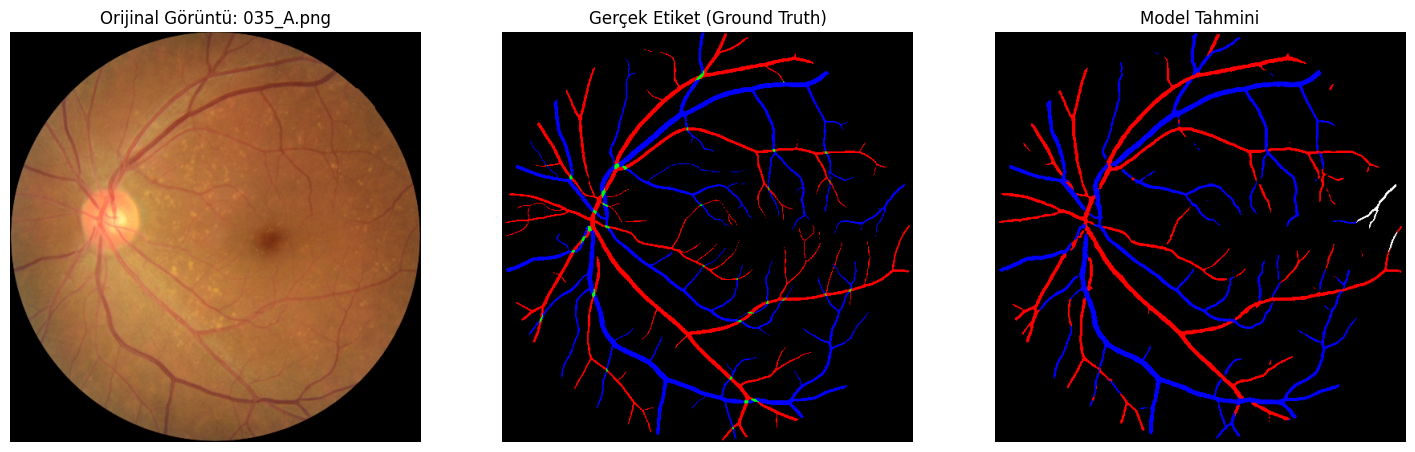

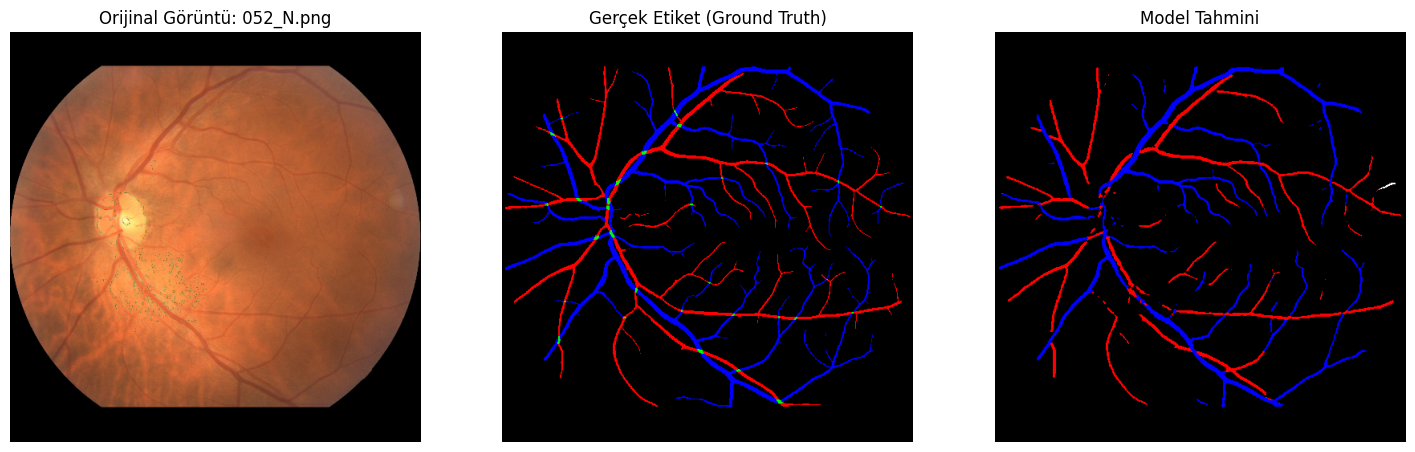

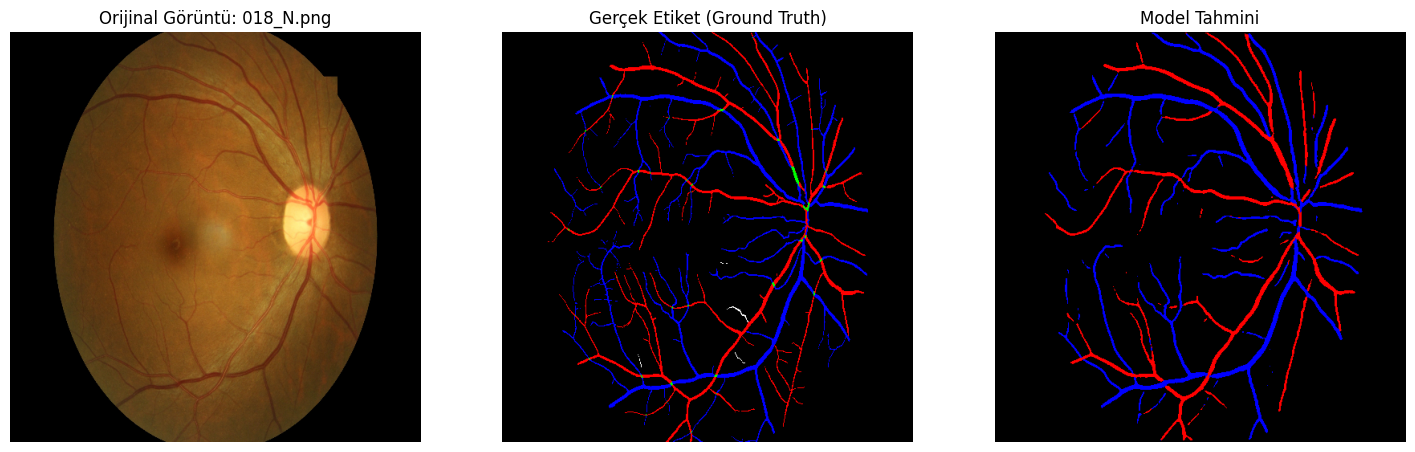

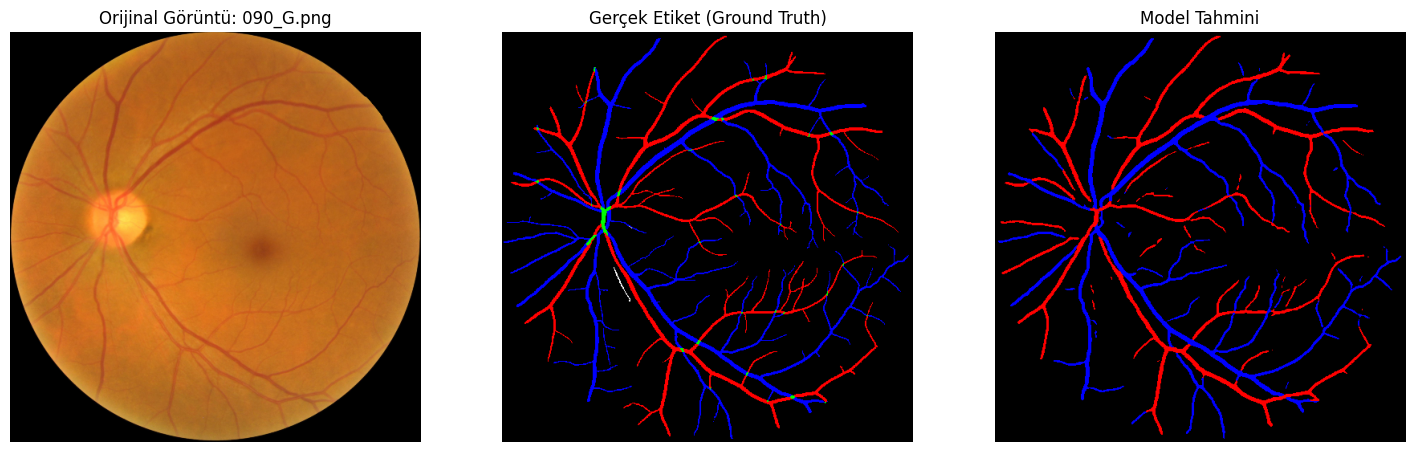

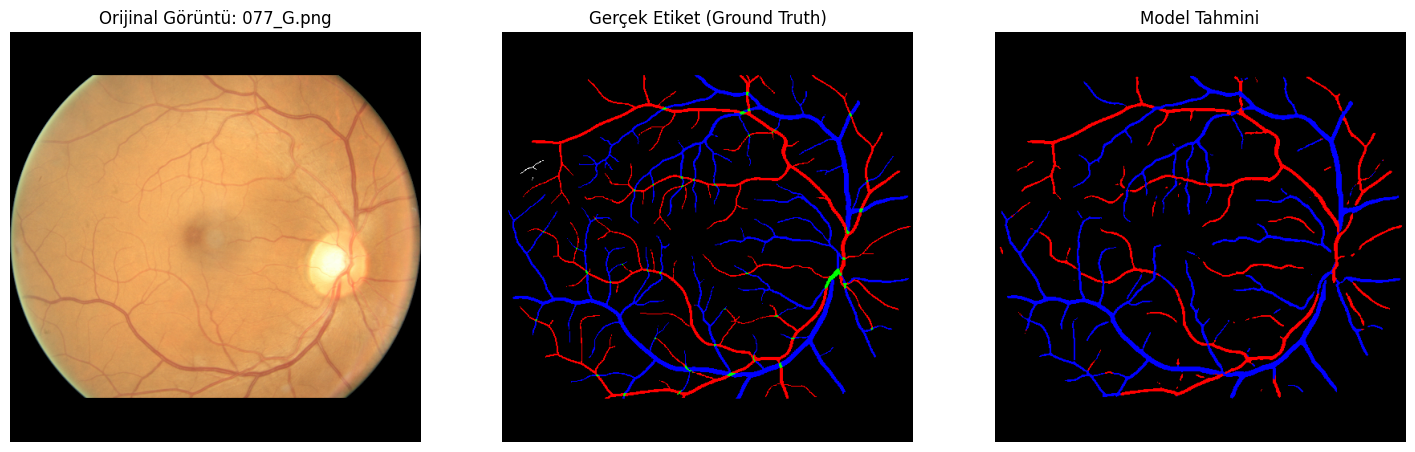


SINIF BAZLI TEST SONUÇLARI
Background   | IoU: 0.9679 | Dice: 0.9837
Artery       | IoU: 0.6221 | Dice: 0.7670
Vein         | IoU: 0.6545 | Dice: 0.7912
Crossing     | IoU: 0.0000 | Dice: 0.0000
Uncertain    | IoU: 0.0693 | Dice: 0.1297
------------------------------
GENEL ORTALAMA | IoU: 0.4628 | Dice: 0.5343


In [6]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader

# 1. Renk Haritası Tanımlama (Makale Standartları)
#
class_colors = {
    0: [0, 0, 0],       # Background (Siyah)
    1: [255, 0, 0],     # Artery (Kırmızı)
    2: [0, 0, 255],     # Vein (Mavi)
    3: [0, 255, 0],     # Crossing (Yeşil)
    4: [255, 255, 255]  # Uncertain (Beyaz)
}

def mask_to_rgb(mask):
    h, w = mask.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    for cls, color in class_colors.items():
        rgb[mask == cls] = color
    return rgb

# 2. Modeli Yükle
model.load_state_dict(torch.load("best_fundus_model_efficient.pth"))
model.eval()

# Tüm test verisini içeren loader (Batch size 1 görselleştirme için idealdir)
test_loader = DataLoader(val_ds, batch_size=1, shuffle=False)

# Metrik Takibi İçin Listeler
all_tp, all_fp, all_fn, all_tn = [], [], [], []
class_names = ["Background", "Artery", "Vein", "Crossing", "Uncertain"]

print(f"--- Test Başlatılıyor (Toplam {len(test_loader)} Görüntü) ---")

with torch.no_grad():
    for i, (image, mask) in enumerate(test_loader):
        image, mask = image.to(DEVICE), mask.to(DEVICE).long()
        output = model(image)
        pred = torch.argmax(output, dim=1)

        # Metrikleri Biriktir
        stats = smp.metrics.get_stats(pred, mask, mode='multiclass', num_classes=5)
        all_tp.append(stats[0]); all_fp.append(stats[1])
        all_fn.append(stats[2]); all_tn.append(stats[3])

        # Görselleştirme (İlk 5 görüntüyü veya hepsini gösterebilirsin)
        if i < 5: # Ekranı çok doldurmaması için sınırlandırabilirsin
            img_np = image[0].cpu().permute(1, 2, 0).numpy()
            # Denormalize (Visualization için)
            img_np = (img_np * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]
            img_np = np.clip(img_np, 0, 1)

            gt_rgb = mask_to_rgb(mask[0].cpu().numpy())
            pred_rgb = mask_to_rgb(pred[0].cpu().numpy())

            plt.figure(figsize=(18, 6))
            plt.subplot(1, 3, 1)
            plt.title(f"Orijinal Görüntü: {val_ds.image_names[i]}")
            plt.imshow(img_np)
            plt.axis('off')

            plt.subplot(1, 3, 2)
            plt.title("Gerçek Etiket (Ground Truth)")
            plt.imshow(gt_rgb)
            plt.axis('off')

            plt.subplot(1, 3, 3)
            plt.title("Model Tahmini")
            plt.imshow(pred_rgb)
            plt.axis('off')
            plt.show()

# 3. Nihai Metrik Hesaplama (Tüm Test Seti Ortalaması)
#
tp = torch.cat(all_tp); fp = torch.cat(all_fp); fn = torch.cat(all_fn); tn = torch.cat(all_tn)

iou_per_class = smp.metrics.iou_score(tp, fp, fn, tn, reduction="macro")
dice_per_class = smp.metrics.f1_score(tp, fp, fn, tn, reduction="macro")

# Sınıf Bazlı Sonuçları Yazdır
#
print("\n" + "="*30)
print("SINIF BAZLI TEST SONUÇLARI")
print("="*30)
for idx, name in enumerate(class_names):
    # Her sınıfın kendi indeksindeki değerleri al
    c_tp = tp[:, idx].sum(); c_fp = fp[:, idx].sum(); c_fn = fn[:, idx].sum(); c_tn = tn[:, idx].sum()
    
    c_iou = (c_tp / (c_tp + c_fp + c_fn + 1e-7)).item()
    c_dice = (2 * c_tp / (2 * c_tp + c_fp + c_fn + 1e-7)).item()
    
    print(f"{name:12} | IoU: {c_iou:.4f} | Dice: {c_dice:.4f}")

print("-" * 30)
print(f"GENEL ORTALAMA | IoU: {iou_per_class:.4f} | Dice: {dice_per_class:.4f}")
print("=" * 30)

📸 Bulunan görüntü sayısı: 90

🚀 Tahmin başlıyor...



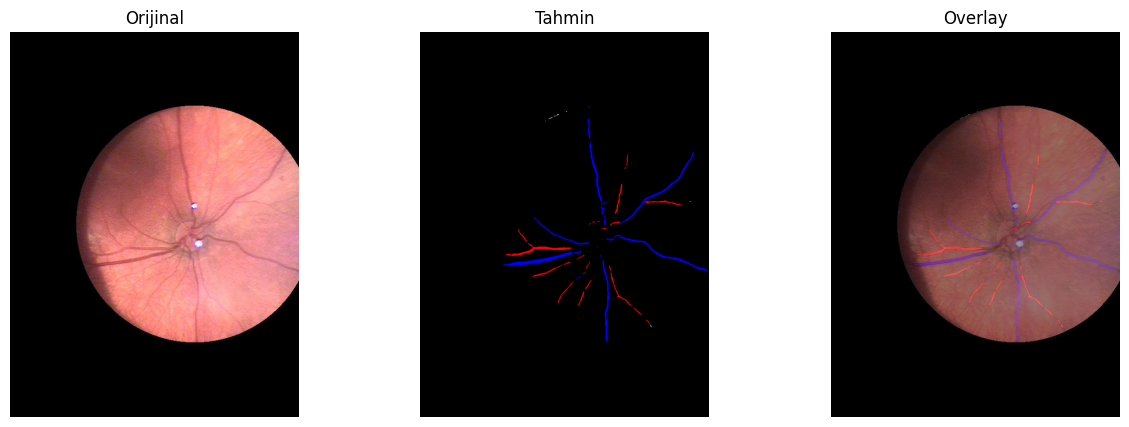

[1/90] ✅ 4_fundus.jpg kaydedildi


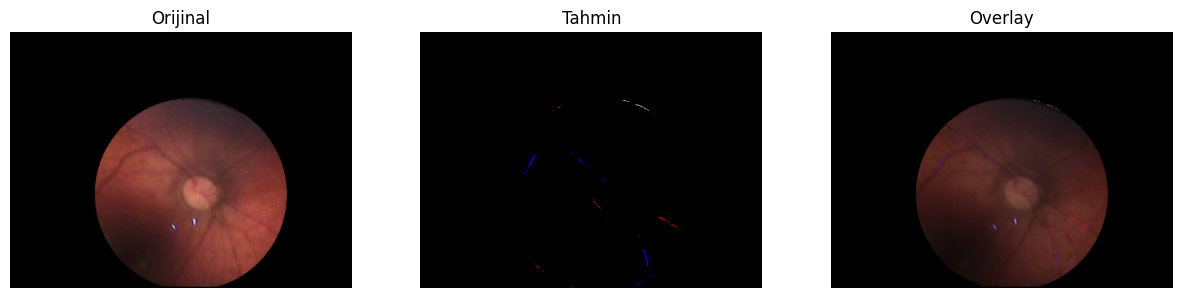

[2/90] ✅ 638741873571634242_fundus.jpg kaydedildi


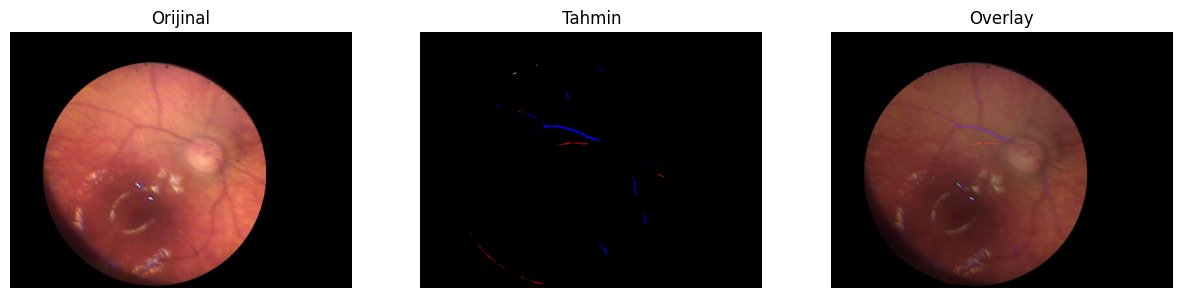

[3/90] ✅ 638741874777059082_fundus.jpg kaydedildi


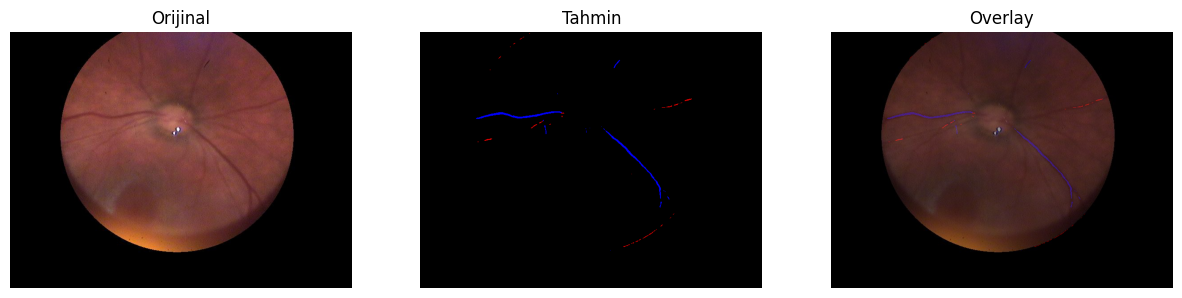

[4/90] ✅ 638741876084170710_fundus.jpg kaydedildi


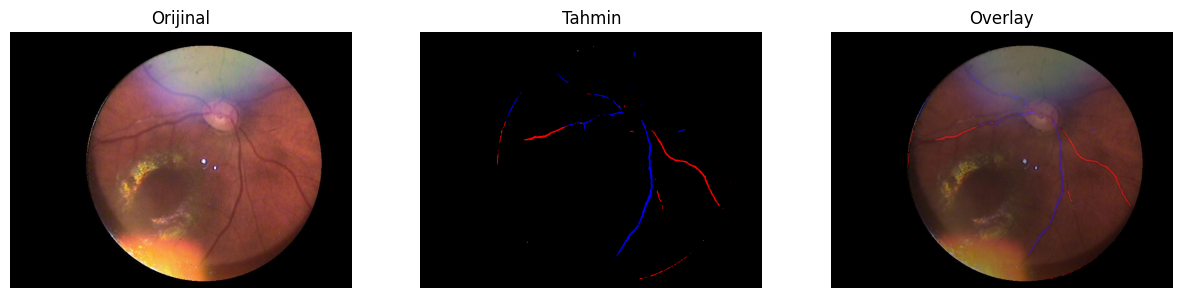

[5/90] ✅ 638741879595544372_fundus.jpg kaydedildi
[6/90] ✅ 638741880712375405_fundus.jpg kaydedildi
[7/90] ✅ 638741881785595074_fundus.jpg kaydedildi
[8/90] ✅ 638741882977666307_fundus.jpg kaydedildi
[9/90] ✅ 638741884326887597_fundus.jpg kaydedildi
[10/90] ✅ 638741885655708132_fundus.jpg kaydedildi
[11/90] ✅ 638741886868089308_fundus.jpg kaydedildi
[12/90] ✅ 638741887805029935_fundus.jpg kaydedildi
[13/90] ✅ 638741890241600270_fundus.jpg kaydedildi
[14/90] ✅ 638741892280100015_fundus.jpg kaydedildi
[15/90] ✅ 638741907071521357_fundus.jpg kaydedildi
[16/90] ✅ 638741908658393084_fundus.jpg kaydedildi
[17/90] ✅ 638741913833903641_fundus.jpg kaydedildi
[18/90] ✅ 638741930832150518_fundus.jpg kaydedildi
[19/90] ✅ 638741931880609560_fundus.jpg kaydedildi
[20/90] ✅ 638741934439000298_fundus.jpg kaydedildi
[21/90] ✅ 638741952442771521_fundus.jpg kaydedildi
[22/90] ✅ 638742735559683160_fundus.jpg kaydedildi
[23/90] ✅ 638742787184407475_fundus.jpg kaydedildi
[24/90] ✅ 638742818470508945_fundus.

In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
from torch.utils.data import Dataset, DataLoader
from PIL import Image

# ==============================
# 1. AYARLAR
# ==============================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMAGE_DIR = r"C:\Users\Ayberk\Desktop\rte4togg\BebekSag"
SAVE_DIR = os.path.join(IMAGE_DIR, "predictions")
os.makedirs(SAVE_DIR, exist_ok=True)

# ==============================
# 2. RENK HARİTASI
# ==============================
class_colors = {
    0: [0, 0, 0],       # Background
    1: [255, 0, 0],     # Artery
    2: [0, 0, 255],     # Vein
    3: [0, 255, 0],     # Crossing
    4: [255, 255, 255]  # Uncertain
}

def mask_to_rgb(mask):
    h, w = mask.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    for cls, color in class_colors.items():
        rgb[mask == cls] = color
    return rgb

# ==============================
# 3. DATASET (SAĞLAM VERSİYON)
# ==============================
class TestOnlyDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.transform = transform

        valid_ext = [".png", ".jpg", ".jpeg", ".bmp", ".tif"]
        self.image_names = [
            f for f in os.listdir(image_dir)
            if os.path.splitext(f)[1].lower() in valid_ext
        ]

        print(f"📸 Bulunan görüntü sayısı: {len(self.image_names)}")

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        img_path = os.path.join(self.image_dir, img_name)

        # Önce OpenCV dene
        image = cv2.imread(img_path)

        if image is None:
            # 🔥 fallback → PIL
            try:
                image = Image.open(img_path).convert("RGB")
                image = np.array(image)
            except:
                raise ValueError(f"❌ Görüntü tamamen okunamadı: {img_path}")
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            augmented = self.transform(image=image)
            image = augmented["image"]
        else:
            image = image / 255.0
            image = torch.tensor(image).permute(2, 0, 1).float()

        return image, img_name

# ==============================
# 4. MODEL (BURAYI SEN DOLDUR)
# ==============================




model.load_state_dict(torch.load("best_fundus_model_efficient.pth", map_location=DEVICE))
model.to(DEVICE)
model.eval()

# ==============================
# 5. DATALOADER
# ==============================
test_dataset = TestOnlyDataset(IMAGE_DIR, transform=None)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

# ==============================
# 6. TAHMİN + KAYDETME
# ==============================
print("\n🚀 Tahmin başlıyor...\n")

with torch.no_grad():
    for i, (image, img_name) in enumerate(test_loader):
        image = image.to(DEVICE)

        output = model(image)
        pred = torch.argmax(output, dim=1)

        pred_np = pred[0].cpu().numpy()
        pred_rgb = mask_to_rgb(pred_np)

        # Kaydet
        save_path = os.path.join(SAVE_DIR, img_name[0])
        plt.imsave(save_path, pred_rgb)

        # Görselleştirme
        if i < 5:
            img_np = image[0].cpu().permute(1, 2, 0).numpy()
            img_np = np.clip(img_np, 0, 1)

            overlay = (0.6 * img_np + 0.4 * (pred_rgb / 255)).clip(0, 1)

            plt.figure(figsize=(15, 5))

            plt.subplot(1, 3, 1)
            plt.title("Orijinal")
            plt.imshow(img_np)
            plt.axis('off')

            plt.subplot(1, 3, 2)
            plt.title("Tahmin")
            plt.imshow(pred_rgb)
            plt.axis('off')

            plt.subplot(1, 3, 3)
            plt.title("Overlay")
            plt.imshow(overlay)
            plt.axis('off')

            plt.show()

        print(f"[{i+1}/{len(test_loader)}] ✅ {img_name[0]} kaydedildi")

print("\n🎯 Tüm tahminler tamamlandı!")
print(f"📁 Kayıt klasörü: {SAVE_DIR}")